#Import modules

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

#Import Multi-task ElasticNet

In [ ]:
import joblib

model_1 = joblib.load('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/ElasticNet.pkl')

In [ ]:
model_features = model_1.feature_names_in_
model_features

array(['ENSG00000198712', 'ENSG00000198804', 'ENSG00000198938', ...,
       'ENSG00000197838', 'ENSG00000167751', 'ENSG00000182415'],
      dtype=object)

In [ ]:
import pickle

with open('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/y_train_features.pkl', 'rb') as f:
    y_train_features_loaded = pickle.load(f)

print(y_train_features_loaded)

Index(['1,5-anhydroglucitol (1,5-AG)', '1-arachidonoyl-GPC (20:4n6)',
       '1-arachidonoyl-GPE (20:4n6)', '1-arachidonoyl-GPI (20:4)',
       '1-linoleoylglycerol (18:2)', '1-linoleoyl-GPC (18:2)',
       '1-oleoylglycerol (1-monoolein)', '1-oleoyl-GPE (18:1)',
       '1-palmitoleoyl-GPC (16:1)', '1-palmitoylglycerol (1-monopalmitin)',
       ...
       'urea', 'uridine', 'valine', 'valylglycine', 'xanthine', 'xanthosine',
       '3-phosphoglycerate', 'dehydroascorbate', 'pyruvate',
       'phosphoenolpyruvate (PEP)'],
      dtype='object', length=218)


In [ ]:
metabolite_names = pd.read_csv('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/y_train_tissue_name_map.csv')
metabolite_names = metabolite_names.fillna('No_id')
metabolite_names

,Query,Match,HMDB,PubChem,ChEBI,KEGG,METLIN,SMILES,Comment
0,"1,5-anhydroglucitol (1,5-AG)",No_id,No_id,No_id,No_id,No_id,No_id,No_id,0
1,1-arachidonoyl-GPC (20:4n6),No_id,No_id,No_id,No_id,No_id,No_id,No_id,0
2,1-arachidonoyl-GPE (20:4n6),No_id,No_id,No_id,No_id,No_id,No_id,No_id,0
3,1-arachidonoyl-GPI (20:4),No_id,No_id,No_id,No_id,No_id,No_id,No_id,0
4,1-linoleoylglycerol (18:2),No_id,No_id,No_id,No_id,No_id,No_id,No_id,0
...,...,...,...,...,...,...,...,...,...
213,xanthosine,Xanthosine,HMDB0000299,64959.0,18107.0,C01762,3408.0,OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=NC2=C1N=C(...,1
214,3-phosphoglycerate,3-Phosphoglyceric acid,HMDB0000807,724.0,17050.0,C00597,150.0,OC(COP(O)(O)=O)C(O)=O,1
215,dehydroascorbate,Dehydroascorbic acid,HMDB0001264,440667.0,27956.0,C05422,342.0,[H][C@@]1(OC(=O)C(=O)C1=O)[C@@H](O)CO,1
216,pyruvate,Pyruvic acid,HMDB0000243,1060.0,32816.0,C00022,117.0,CC(=O)C(O)=O,1


In [ ]:
hmdb = {}
for i in y_train_features_loaded:
  if metabolite_names[metabolite_names['Query'] == i]['HMDB'].size > 0:
    hmdb[i] = metabolite_names[metabolite_names['Query'] == i]['HMDB'].values[0]
  else:
    print(f"No matching 'Query' found for '{i}' in metabolite_names.")
    hmdb[i] = 'No_id'

No matching 'Query' found for 'linolenate [alpha or gamma; (18:3n3 or 6)]' in metabolite_names.
No matching 'Query' found for 'tryptophan betaine ' in metabolite_names.


In [ ]:
y_train_features_loaded_hmdb = []
for i in y_train_features_loaded:
 y_train_features_loaded_hmdb.append(hmdb[i])
len(y_train_features_loaded_hmdb)

218

In [ ]:
y_train_features_loaded = y_train_features_loaded_hmdb

#Import Random forest regressor

In [ ]:
model_2 = joblib.load('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/Random Forest Regressor.pkl')

#Import ensemble

In [ ]:
final_estimator = joblib.load('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/Ensemble.pkl')

#RNA sequencing data

In [ ]:
rna = pd.read_csv('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/Fudan_data_processed/fudan_tpm_met_genes_y_features.csv', index_col = 0)
rna

,ENSG00000198712,ENSG00000198804,ENSG00000198938,ENSG00000198899,ENSG00000198886,ENSG00000212907,ENSG00000198763,ENSG00000198840,ENSG00000156508,ENSG00000198888,...,ENSG00000205923,ENSG00000183747,ENSG00000066813,ENSG00000182601,ENSG00000156885,ENSG00000182156,ENSG00000166948,ENSG00000197838,ENSG00000167751,ENSG00000182415
FUSCCTNBC182,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,956.960040,NaN,...,0.524713,0.017710,0.000000,3.203689,0.000000,0.247250,0.0,0.0,0.091410,0.0
FUSCCTNBC203,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1264.796635,NaN,...,0.146962,0.049603,0.000000,17.591684,0.000000,0.115417,0.0,0.0,0.032003,0.0
FUSCCTNBC202,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1128.969744,NaN,...,0.712123,0.000000,0.217303,5.720976,0.000000,0.279633,0.0,0.0,1.643769,0.0
FUSCCTNBC252,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1747.266355,NaN,...,0.000000,0.019548,0.000000,2.698692,0.000000,0.136456,0.0,0.0,0.025224,0.0
FUSCCTNBC187,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1385.507343,NaN,...,1.427101,0.034406,0.017281,20.841528,0.000000,0.040028,0.0,0.0,0.022198,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FUSCCTNBC478,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1044.355445,NaN,...,0.145471,0.049100,0.000000,147.135098,0.000000,0.456981,0.0,0.0,0.031678,0.0
FUSCCTNBC475,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1095.808585,NaN,...,0.000000,0.015217,0.000000,7.823638,0.000000,0.247857,0.0,0.0,0.019636,0.0
FUSCCTNBC476,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,708.611839,NaN,...,0.333701,0.000000,0.028286,3.217018,0.487852,0.065518,0.0,0.0,0.072667,0.0
FUSCCTNBC479,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1110.229721,NaN,...,0.435596,0.122520,0.000000,23.096309,0.000000,0.228063,0.0,0.0,0.126474,0.0


In [ ]:
rna = rna.apply(lambda x: np.log2(x + 1))
rna.head(3)

,ENSG00000198712,ENSG00000198804,ENSG00000198938,ENSG00000198899,ENSG00000198886,ENSG00000212907,ENSG00000198763,ENSG00000198840,ENSG00000156508,ENSG00000198888,...,ENSG00000205923,ENSG00000183747,ENSG00000066813,ENSG00000182601,ENSG00000156885,ENSG00000182156,ENSG00000166948,ENSG00000197838,ENSG00000167751,ENSG00000182415
FUSCCTNBC182,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.903822,NaN,...,0.608537,0.025327,0.000000,2.071656,0.0,0.318750,0.0,0.0,0.126193,0.0
FUSCCTNBC203,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.305830,NaN,...,0.197818,0.069844,0.000000,4.216586,0.0,0.157583,0.0,0.0,0.045447,0.0
FUSCCTNBC202,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.142068,NaN,...,0.775786,0.000000,0.283688,2.748671,0.0,0.355730,0.0,0.0,1.402596,0.0


#Metabolite prediction

In [ ]:
def filter_model_features(df):
  filtered_data = df[model_features]
  return filtered_data

In [ ]:
rna_filtered = filter_model_features(rna)

In [ ]:
rna_filtered.head(2)

,ENSG00000198712,ENSG00000198804,ENSG00000198938,ENSG00000198899,ENSG00000198886,ENSG00000212907,ENSG00000198763,ENSG00000198840,ENSG00000156508,ENSG00000198888,...,ENSG00000205923,ENSG00000183747,ENSG00000066813,ENSG00000182601,ENSG00000156885,ENSG00000182156,ENSG00000166948,ENSG00000197838,ENSG00000167751,ENSG00000182415
FUSCCTNBC182,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.903822,NaN,...,0.608537,0.025327,0.0,2.071656,0.0,0.318750,0.0,0.0,0.126193,0.0
FUSCCTNBC203,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.305830,NaN,...,0.197818,0.069844,0.0,4.216586,0.0,0.157583,0.0,0.0,0.045447,0.0


In [ ]:
def predict_metabolites(model, filtered_data):
  pred_metabolites = model.predict(filtered_data)
  pred_metabolites = pd.DataFrame(pred_metabolites, index = filtered_data.index, columns = y_train_features_loaded)
  return pred_metabolites

In [ ]:
#Elastic Net predictions
rna_pred_elastic = predict_metabolites(model_1, rna_filtered)

#Random forest regressor predictions
rna_pred_rf = predict_metabolites(model_2, rna_filtered)

In [ ]:
#Ensemble predictions

def predict_metabolites_ensemble(model_1, model_2, final_estimator, filtered_data):
  pred_1 = model_1.predict(filtered_data)
  pred_2 = model_2.predict(filtered_data)
  stacked_preds = np.hstack([pred_1, pred_2])
  pred_metabolites = final_estimator.predict(stacked_preds)
  pred_metabolites = pd.DataFrame(pred_metabolites, index = filtered_data.index, columns = y_train_features_loaded)

  return pred_metabolites

rna_pred_ensemble = predict_metabolites_ensemble(model_1, model_2, final_estimator, rna_filtered)

In [ ]:
rna_pred_ensemble

,No_id,No_id,No_id,No_id,No_id,HMDB0010386,HMDB0011567,No_id,No_id,No_id,...,HMDB0000294,HMDB0000296,HMDB0000883,HMDB0029127,HMDB0000292,HMDB0000299,HMDB0000807,HMDB0001264,HMDB0000243,HMDB0000263
FUSCCTNBC182,21.257539,19.341044,26.716465,22.351462,20.128613,21.733506,21.645404,21.782142,19.303347,23.342090,...,21.960296,19.439959,25.511360,18.813524,22.960210,16.866518,19.363134,15.509789,21.956034,19.696538
FUSCCTNBC203,22.321402,20.242076,27.923796,23.017173,20.778425,22.941351,21.595815,22.686360,20.205131,23.607850,...,22.188230,19.108198,26.088291,20.890361,22.963302,17.527011,19.478805,16.345176,23.577163,20.934048
FUSCCTNBC202,22.698735,21.405273,28.617816,23.646420,22.667385,24.339670,22.861078,24.014327,20.579690,23.926371,...,22.394722,18.472518,26.268270,21.549338,22.886418,17.312622,19.455189,16.180463,24.300367,20.337122
FUSCCTNBC252,21.698935,20.173799,27.588583,22.843352,20.919581,22.241238,21.844499,22.418764,19.698438,24.068988,...,22.009602,18.465016,25.643361,19.917769,22.905278,17.255196,19.997655,17.521807,24.296756,18.870677
FUSCCTNBC187,22.557134,20.766887,29.659165,23.549326,20.630998,23.774179,20.922438,21.953605,19.399706,22.897108,...,23.498958,16.780410,25.477206,23.179816,21.125679,17.294350,19.471490,17.502986,26.061383,19.621418
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FUSCCTNBC478,22.684033,20.606208,29.250986,23.403300,19.882450,23.446141,20.431470,21.484129,18.982401,22.842289,...,22.976977,16.965995,25.031926,22.897062,20.845593,17.547740,19.518465,17.796936,25.911862,19.217389
FUSCCTNBC475,24.691836,23.139770,35.263049,25.613289,22.301363,26.771474,21.119369,23.462307,19.754999,23.535627,...,23.546033,11.337636,24.572268,27.875643,18.941019,18.569607,20.816533,19.275283,32.504283,19.981627
FUSCCTNBC476,21.669751,20.245428,28.950455,23.495459,21.541353,23.155518,23.007511,23.933993,20.686522,24.899856,...,21.306938,19.309716,25.974144,19.620094,24.107782,17.376638,19.962356,15.683751,23.320258,20.085730
FUSCCTNBC479,22.389090,20.428215,27.306263,22.627311,20.476323,23.399521,21.269190,22.031881,19.681801,23.177444,...,22.973665,18.419362,25.378693,21.607731,22.025441,17.729708,19.260324,17.557014,23.792761,19.527136


#LCMS data

In [ ]:
lcms = pd.read_csv('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/Fudan_data_processed/metabolites_fudan_hmdb.csv', index_col = 0)
lcms

,HMDB0000050,HMDB0003229,HMDB0000220,HMDB0000214,HMDB0001173,HMDB0000089,HMDB0000161,HMDB0000939,HMDB0000126,HMDB0000696,...,HMDB0000532,HMDB0000714,HMDB0011172,HMDB0000243,HMDB0000011,HMDB0000094,HMDB0000194,HMDB0002994,HMDB0000125,HMDB0000056
FUSCCTNBC002,21.291669,17.379201,19.533546,14.752381,17.281514,13.438272,15.498725,15.460840,17.108708,18.389594,...,15.014544,16.147682,14.095067,19.686661,11.607330,15.498725,15.209910,17.454026,14.036174,12.963980
FUSCCTNBC049,22.449926,16.339084,19.881713,14.788514,19.866545,13.159556,15.739253,15.798674,14.671762,18.054933,...,14.693705,13.076816,13.666224,20.624987,13.371777,16.040461,14.952195,14.508042,13.938477,12.983706
FUSCCTNBC053,23.202486,17.216357,19.696190,14.371777,17.997979,14.010178,14.970286,16.732366,14.027560,18.714715,...,14.747144,12.264443,14.609640,21.766542,11.264443,16.055367,14.778283,11.903129,14.103288,12.593391
FUSCCTNBC060,22.470636,16.215609,20.109475,16.133704,18.747767,13.872675,16.031873,15.855744,15.247483,18.138002,...,13.699139,14.720672,13.666224,20.864579,13.024101,16.395400,13.992584,15.798674,14.258566,12.967587
FUSCCTNBC061,22.773308,17.616161,19.755466,16.446373,20.537163,14.143702,14.344296,15.646671,17.253183,18.775350,...,16.169377,17.936161,16.866820,21.061099,13.168985,17.718038,14.036174,12.576957,10.987264,13.091766
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FUSCCTNBC100_N,21.764207,16.881198,20.037044,16.145693,2.378512,13.138912,15.457637,14.773139,14.988152,18.232852,...,13.938477,16.962738,12.246741,20.862873,14.919981,16.473579,14.309192,14.838613,13.451211,13.586371
FUSCCTNBC057_N,20.592852,16.970218,20.405553,16.080568,18.882330,13.501837,15.723341,15.660664,9.324181,17.181570,...,2.691534,16.589300,10.569856,20.332841,13.803728,16.982459,11.316282,14.660664,13.344296,12.987264
FUSCCTNBC252_N,18.964724,17.817633,20.577451,15.589300,2.715893,12.859146,14.580494,13.853310,14.747144,14.470405,...,12.912515,12.956739,12.240791,20.039388,12.943980,17.606644,13.992584,12.369052,2.715893,2.715893
FUSCCTNBC068_N,21.215000,16.183015,20.249903,15.912983,18.598798,13.699139,15.693705,15.111462,12.225810,17.796990,...,2.469886,13.249706,12.655083,20.496816,13.148477,16.512679,14.905951,14.258566,13.688250,12.819780


#Model assessment

In [ ]:
from scipy.stats import spearmanr

metabolites_spearman_positive_all = {}
metabolites_spearman_negative_all = {}

def plot_spearman_per_metabolite(y_pred, y_true, model_name):
    """Plots the Spearman's correlation coefficient per metabolite."""

    spearman_coeffs = []
    for i in range(y_true.shape[1]):
        coeff, _ = spearmanr(y_true.iloc[:, i], y_pred.iloc[:, i])
        spearman_coeffs.append(coeff)

    # Create a DataFrame for sorting
    spearman_df = pd.DataFrame({'Metabolite': y_true.columns, 'Spearman Coefficient': spearman_coeffs})

    # Sort the DataFrame by Spearman's coefficients in descending order
    spearman_df = spearman_df.sort_values(by=['Spearman Coefficient'], ascending=False)
    metabolites_spearman_positive = spearman_df[spearman_df['Spearman Coefficient'] > 0]
    metabolites_spearman_positive_all[model_name] = list(metabolites_spearman_positive['Metabolite'])
    metabolites_spearman_negative = spearman_df[spearman_df['Spearman Coefficient'] < 0]
    metabolites_spearman_negative_all[model_name] = list(metabolites_spearman_negative['Metabolite'])


    # Plotting
    plt.figure(figsize=(10, 6))
    plt.title(f"Spearman's Correlation Coefficient per Metabolite ({model_name} - Fudan)")
    plt.bar(range(len(spearman_df)), spearman_df['Spearman Coefficient'])
    plt.xticks()
    plt.xlabel("Metabolite")
    plt.savefig(f'drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/Spearmans Corr per metabolite({model_name} Fudan.svg', bbox_inches = 'tight')
    plt.show()

In [ ]:
def get_spearman_correlation(y_pred, y_true, model_name):

  correlation, p_value = spearmanr(y_true, y_pred)

  # Use .values.ravel() or .to_numpy().flatten()
  correlation_df = pd.DataFrame({'Actual': y_true.values.ravel(), 'Predicted': y_pred.values.ravel()})

  # Calculate Spearman's correlation
  correlation, p_value = spearmanr(correlation_df['Actual'], correlation_df['Predicted'])

  # Add correlation and p-value to DataFrame
  correlation_df['Correlation'] = correlation
  correlation_df['P-value'] = p_value

  sns.regplot(x='Actual', y='Predicted', data=correlation_df, line_kws={'color': 'red'})
  plt.title(f'Spearman\'s Correlation ({model_name} - Fudan)')
  plt.xlabel('Actual Values')
  plt.ylabel('Predicted Values')

  # Add correlation and p-value as text
  plt.text(0.1, 0.9, f'Correlation: {correlation:.2f}\nP-value: {p_value:.2f}', transform=plt.gca().transAxes)
  plt.savefig(f'drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/Spearmans Corr ({model_name} Fudan).svg', bbox_inches = 'tight')
  plt.show()

In [ ]:
from collections import Counter


def analyse_predictions(rna_pred_elastic, rna_pred_rf, rna_pred_ensemble, lcms):

  #Make sure the columns are the same
  lcms = lcms[list(set(lcms.columns).intersection(set(rna_pred_elastic.columns)))]
  rna_pred_elastic = rna_pred_elastic[list(set(lcms.columns).intersection(set(rna_pred_elastic.columns)))]
  rna_pred_rf = rna_pred_rf[list(set(lcms.columns).intersection(set(rna_pred_rf.columns)))]
  rna_pred_ensemble = rna_pred_ensemble[list(set(lcms.columns).intersection(set(rna_pred_ensemble.columns)))]

  #Make sure the indexes are the same
  lcms = lcms.loc[list(set(lcms.index).intersection(set(rna_pred_elastic.index)))]
  rna_pred_elastic = rna_pred_elastic.loc[list(set(lcms.index).intersection(set(rna_pred_elastic.index)))]
  rna_pred_rf = rna_pred_rf.loc[list(set(lcms.index).intersection(set(rna_pred_rf.index)))]
  rna_pred_ensemble = rna_pred_ensemble.loc[list(set(lcms.index).intersection(set(rna_pred_ensemble.index)))]

  #Drop column that has duplicate HMDB id ()
  counts = Counter(rna_pred_elastic.columns)
  duplicates = [item for item, count in counts.items() if count > 1]
  lcms = lcms.drop(columns = duplicates)
  rna_pred_elastic = rna_pred_elastic.drop(columns = duplicates)
  rna_pred_rf = rna_pred_rf.drop(columns = duplicates)
  rna_pred_ensemble = rna_pred_ensemble.drop(columns = duplicates)

  #Get plots

  #Spearman per metabolite
  plot_spearman_per_metabolite(y_pred = rna_pred_elastic, y_true = lcms, model_name = 'Elastic Net')
  plot_spearman_per_metabolite(y_pred = rna_pred_rf, y_true = lcms, model_name = 'Random Forest Regressor')
  plot_spearman_per_metabolite(y_pred = rna_pred_ensemble, y_true = lcms, model_name = 'Ensemble')

  #Spearman for the whole dataset
  get_spearman_correlation(y_pred = rna_pred_elastic, y_true = lcms, model_name = 'Elastic Net')
  get_spearman_correlation(y_pred = rna_pred_rf, y_true = lcms, model_name = 'Random Forest Regressor')
  get_spearman_correlation(y_pred = rna_pred_ensemble, y_true = lcms, model_name = 'Ensemble')

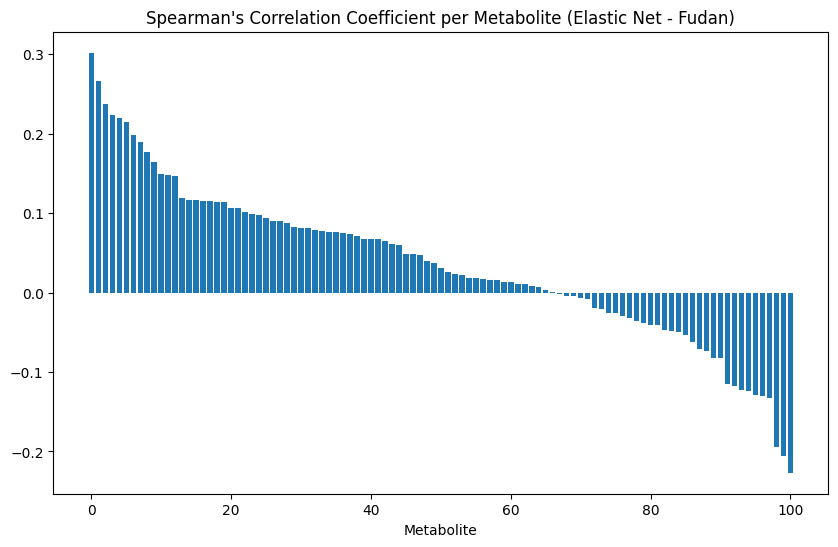

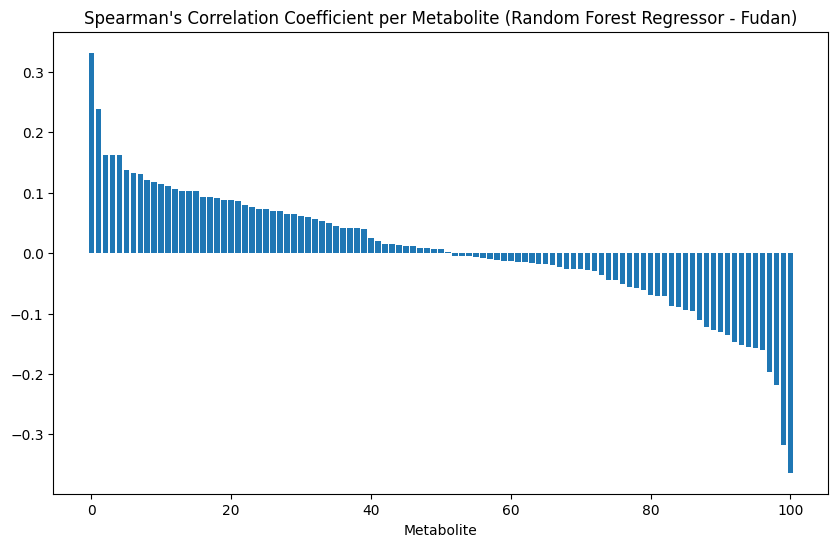

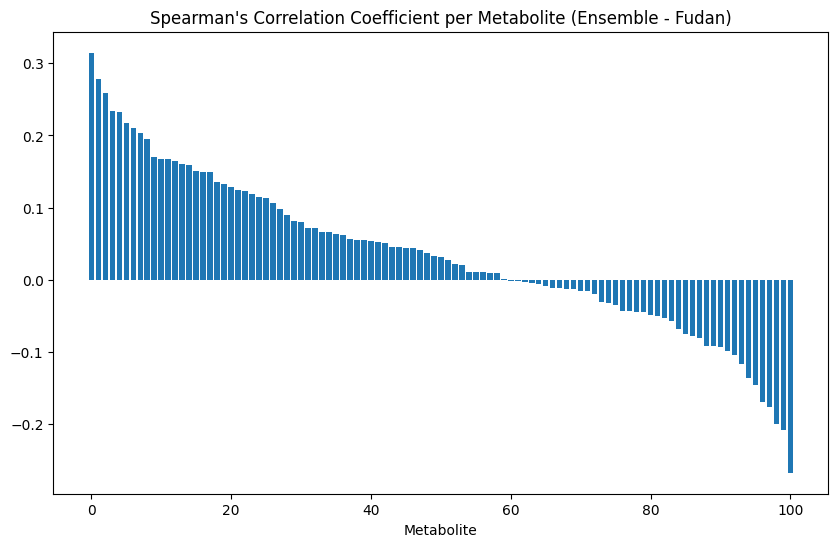

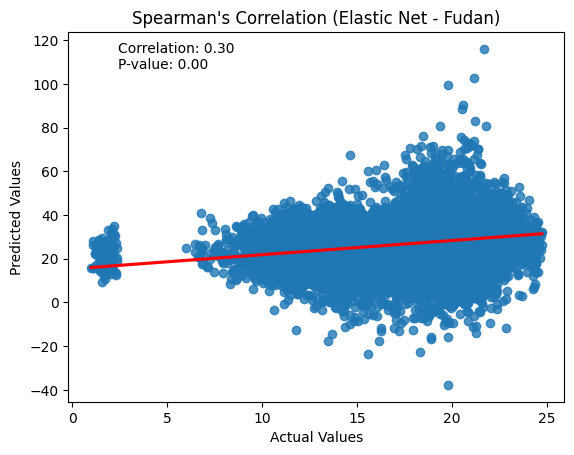

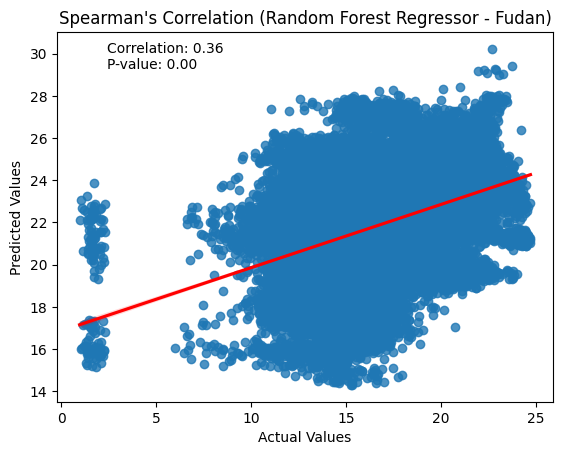

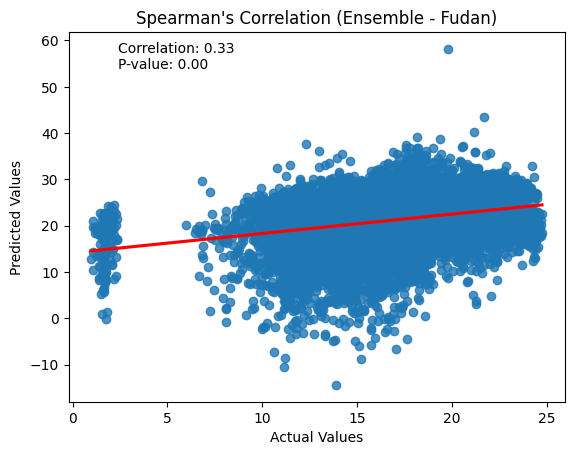

In [ ]:
analyse_predictions(rna_pred_elastic = rna_pred_elastic, rna_pred_rf = rna_pred_rf, rna_pred_ensemble = rna_pred_ensemble, lcms = lcms)

In [ ]:
with open('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/metabolites_spearman_positive_all.pkl', 'wb') as file:
    pickle.dump(metabolites_spearman_positive_all, file)

In [ ]:
metabolites_spearman_positive_all

{'Elastic Net': ['HMDB0003337',
  'HMDB0000071',
  'HMDB0002259',
  'HMDB0000056',
  'HMDB0000148',
  'HMDB0000267',
  'HMDB0000641',
  'HMDB0000904',
  'HMDB0006344',
  'HMDB0000167',
  'HMDB0000182',
  'HMDB0000625',
  'HMDB0000826',
  'HMDB0000251',
  'HMDB0000660',
  'HMDB0002000',
  'HMDB0000755',
  'HMDB0000169',
  'HMDB0000159',
  'HMDB0003229',
  'HMDB0000163',
  'HMDB0000848',
  'HMDB0000252',
  'HMDB0000294',
  'HMDB0000767',
  'HMDB0000517',
  'HMDB0000827',
  'HMDB0000929',
  'HMDB0000283',
  'HMDB0000062',
  'HMDB0000262',
  'HMDB0000806',
  'HMDB0000187',
  'HMDB0000939',
  'HMDB0000682',
  'HMDB0011503',
  'HMDB0000220',
  'HMDB0000870',
  'HMDB0000210',
  'HMDB0000050',
  'HMDB0000638',
  'HMDB0000123',
  'HMDB0000214',
  'HMDB0000684',
  'HMDB0000034',
  'HMDB0000943',
  'HMDB0000714',
  'HMDB0000296',
  'HMDB0000162',
  'HMDB0001173',
  'HMDB0000157',
  'HMDB0000687',
  'HMDB0001565',
  'HMDB0000043',
  'HMDB0000158',
  'HMDB0000086',
  'HMDB0000883',
  'HMDB0000673',

In [ ]:
metabolites_spearman_negative_all

{'Elastic Net': ['HMDB0000211',
  'HMDB0010382',
  'HMDB0000125',
  'HMDB0028691',
  'HMDB0000133',
  'HMDB0000089',
  'HMDB0003045',
  'HMDB0011737',
  'HMDB0000191',
  'HMDB0000201',
  'HMDB0000161',
  'HMDB0000224',
  'HMDB0001406',
  'HMDB0001316',
  'HMDB0000696',
  'HMDB0000139',
  'HMDB0011172',
  'HMDB0000195',
  'HMDB0000168',
  'HMDB0000254',
  'HMDB0000594',
  'HMDB0000156',
  'HMDB0000177',
  'HMDB0002994',
  'HMDB0000011',
  'HMDB0001348',
  'HMDB0000097',
  'HMDB0000766',
  'HMDB0000094',
  'HMDB0000695',
  'HMDB0000131',
  'HMDB0000243',
  'HMDB0000126',
  'HMDB0001262'],
 'Random Forest Regressor': ['HMDB0000214',
  'HMDB0000158',
  'HMDB0000673',
  'HMDB0002000',
  'HMDB0000159',
  'HMDB0000296',
  'HMDB0000812',
  'HMDB0000168',
  'HMDB0000883',
  'HMDB0001565',
  'HMDB0000191',
  'HMDB0002259',
  'HMDB0000156',
  'HMDB0000517',
  'HMDB0000134',
  'HMDB0000131',
  'HMDB0000625',
  'HMDB0000289',
  'HMDB0000294',
  'HMDB0000125',
  'HMDB0000177',
  'HMDB0003229',
  'HM

In [ ]:
positive = {}
for item in metabolites_spearman_positive_all:
  positive[item] = len(metabolites_spearman_positive_all[item])
  print(item, len(metabolites_spearman_positive_all[item]))
positive = pd.DataFrame(positive, index = [0])
positive.rename(index = {0 : 'Positive'}, inplace = True)
positive

Elastic Net 67
Random Forest Regressor 52
Ensemble 60


,Elastic Net,Random Forest Regressor,Ensemble
Positive,67,52,60


In [ ]:
negative = {}
for item in metabolites_spearman_negative_all:
  negative[item] = len(metabolites_spearman_negative_all[item])
  print(item, len(metabolites_spearman_negative_all[item]))
negative = pd.DataFrame(negative, index = [0])
negative.rename(index = {0 : 'Negative'}, inplace = True)
negative

Elastic Net 34
Random Forest Regressor 49
Ensemble 41


,Elastic Net,Random Forest Regressor,Ensemble
Negative,34,49,41


In [ ]:
pos_neg = pd.concat([positive, negative], axis = 0)
pos_neg = pos_neg.T
pos_neg

,Positive,Negative
Elastic Net,67,34
Random Forest Regressor,52,49
Ensemble,60,41


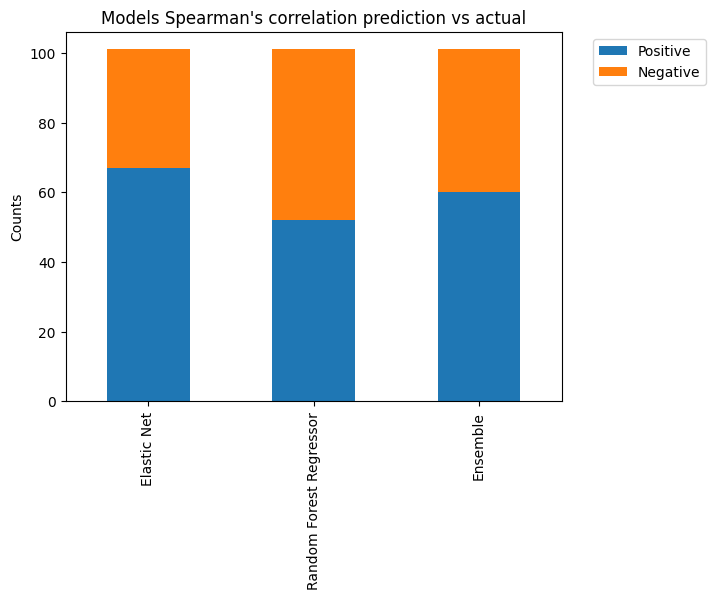

In [ ]:
pos_neg.plot(kind = 'bar', stacked = True)
plt.legend(bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.title("Models Spearman's correlation prediction vs actual")
plt.ylabel('Counts')
plt.savefig('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/Fudan_model_comparison_spearmans.svg', bbox_inches = 'tight')
plt.show()

#MYC case study

In [ ]:
cnv = pd.read_csv('drive/My Drive/Colab Notebooks/GP_lab_data/BRCA1_project/Fudan_TripleNegative/FUSCC_TNBC_annotation_withCNV.txt', sep = '\t')
cnv

,Transcriptomic_Sample,Tumour,HR_status,HER2_status,TNBC_status,PI3K_mutation_status,PTEN_status,PI3K_activity_status,MYC_status
0,FUSCCTNBC001,Tumor,HR-,HER2-,TNBC+,PI3K_mut,PTEN_WT,PI3K_PTEN_mut,MYC_Gain
1,FUSCCTNBC003,Tumor,HR-,HER2-,TNBC+,NaN,NaN,NaN,NaN
2,FUSCCTNBC004,Tumor,HR-,HER2-,TNBC+,NaN,PTEN_Deletion,PI3K_PTEN_mut,MYC_Amplification
3,FUSCCTNBC005,Tumor,HR-,HER2-,TNBC+,PI3K_mut,PTEN_Deletion,PI3K_PTEN_mut,MYC_Amplification
4,FUSCCTNBC006,Tumor,HR-,HER2-,TNBC+,PI3K_WT,PTEN_Gain,PI3K_PTEN_WT,MYC_Gain
...,...,...,...,...,...,...,...,...,...
313,FUSCCTNBC491,Tumor,HR-,HER2-,TNBC+,NaN,NaN,NaN,NaN
314,FUSCCTNBC492,Tumor,HR-,HER2-,TNBC+,NaN,NaN,NaN,NaN
315,FUSCCTNBC493,Tumor,HR-,HER2-,TNBC+,NaN,NaN,NaN,NaN
316,FUSCCTNBC494,Tumor,HR-,HER2-,TNBC+,NaN,NaN,NaN,NaN


In [ ]:
cnv.MYC_status.value_counts()

,count
MYC_status,
MYC_Gain,99
MYC_Amplification,88
MYC_WT,71
MYC_Deletion,5


In [ ]:
myc = cnv[['Transcriptomic_Sample', 'MYC_status']]
myc = myc.dropna()
myc

,Transcriptomic_Sample,MYC_status
0,FUSCCTNBC001,MYC_Gain
2,FUSCCTNBC004,MYC_Amplification
3,FUSCCTNBC005,MYC_Amplification
4,FUSCCTNBC006,MYC_Gain
5,FUSCCTNBC007,MYC_Amplification
...,...,...
282,FUSCCTNBC458,MYC_Amplification
284,FUSCCTNBC461,MYC_Amplification
287,FUSCCTNBC465,MYC_Gain
289,FUSCCTNBC467,MYC_Gain


In [ ]:
myc.MYC_status.isna().sum()

np.int64(0)

In [ ]:
myc_status = []
for i in myc.MYC_status:
  if i in ['MYC_Gain', 'MYC_Amplification']:
    myc_status.append('Gain/Amplification')
  else:
    myc_status.append('Loss/No_change')

In [ ]:
myc['MYC'] = myc_status
myc = myc.set_index('Transcriptomic_Sample').drop('MYC_status', axis = 'columns')
myc

,MYC
Transcriptomic_Sample,
FUSCCTNBC001,Gain/Amplification
FUSCCTNBC004,Gain/Amplification
FUSCCTNBC005,Gain/Amplification
FUSCCTNBC006,Gain/Amplification
FUSCCTNBC007,Gain/Amplification
...,...
FUSCCTNBC458,Gain/Amplification
FUSCCTNBC461,Gain/Amplification
FUSCCTNBC465,Gain/Amplification


In [ ]:
myc = myc.loc[myc.index.intersection(lcms.index)]
myc

,MYC
FUSCCTNBC001,Gain/Amplification
FUSCCTNBC004,Gain/Amplification
FUSCCTNBC005,Gain/Amplification
FUSCCTNBC006,Gain/Amplification
FUSCCTNBC007,Gain/Amplification
...,...
FUSCCTNBC441,Gain/Amplification
FUSCCTNBC443,Loss/No_change
FUSCCTNBC451,Loss/No_change
FUSCCTNBC456,Loss/No_change


In [ ]:
myc.MYC.value_counts()

,count
MYC,
Gain/Amplification,139
Loss/No_change,59


In [ ]:
def select_and_add_myc_status(df, myc_df):
  common_index = list(df.index.intersection(myc_df.index))
  res = pd.concat([myc_df.loc[common_index], df.loc[common_index]], axis = 'columns')
  return res

In [ ]:
rna_pred_ensemble

,No_id,No_id,No_id,No_id,No_id,HMDB0010386,HMDB0011567,No_id,No_id,No_id,...,HMDB0000294,HMDB0000296,HMDB0000883,HMDB0029127,HMDB0000292,HMDB0000299,HMDB0000807,HMDB0001264,HMDB0000243,HMDB0000263
FUSCCTNBC182,21.257539,19.341044,26.716465,22.351462,20.128613,21.733506,21.645404,21.782142,19.303347,23.342090,...,21.960296,19.439959,25.511360,18.813524,22.960210,16.866518,19.363134,15.509789,21.956034,19.696538
FUSCCTNBC203,22.321402,20.242076,27.923796,23.017173,20.778425,22.941351,21.595815,22.686360,20.205131,23.607850,...,22.188230,19.108198,26.088291,20.890361,22.963302,17.527011,19.478805,16.345176,23.577163,20.934048
FUSCCTNBC202,22.698735,21.405273,28.617816,23.646420,22.667385,24.339670,22.861078,24.014327,20.579690,23.926371,...,22.394722,18.472518,26.268270,21.549338,22.886418,17.312622,19.455189,16.180463,24.300367,20.337122
FUSCCTNBC252,21.698935,20.173799,27.588583,22.843352,20.919581,22.241238,21.844499,22.418764,19.698438,24.068988,...,22.009602,18.465016,25.643361,19.917769,22.905278,17.255196,19.997655,17.521807,24.296756,18.870677
FUSCCTNBC187,22.557134,20.766887,29.659165,23.549326,20.630998,23.774179,20.922438,21.953605,19.399706,22.897108,...,23.498958,16.780410,25.477206,23.179816,21.125679,17.294350,19.471490,17.502986,26.061383,19.621418
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FUSCCTNBC478,22.684033,20.606208,29.250986,23.403300,19.882450,23.446141,20.431470,21.484129,18.982401,22.842289,...,22.976977,16.965995,25.031926,22.897062,20.845593,17.547740,19.518465,17.796936,25.911862,19.217389
FUSCCTNBC475,24.691836,23.139770,35.263049,25.613289,22.301363,26.771474,21.119369,23.462307,19.754999,23.535627,...,23.546033,11.337636,24.572268,27.875643,18.941019,18.569607,20.816533,19.275283,32.504283,19.981627
FUSCCTNBC476,21.669751,20.245428,28.950455,23.495459,21.541353,23.155518,23.007511,23.933993,20.686522,24.899856,...,21.306938,19.309716,25.974144,19.620094,24.107782,17.376638,19.962356,15.683751,23.320258,20.085730
FUSCCTNBC479,22.389090,20.428215,27.306263,22.627311,20.476323,23.399521,21.269190,22.031881,19.681801,23.177444,...,22.973665,18.419362,25.378693,21.607731,22.025441,17.729708,19.260324,17.557014,23.792761,19.527136


In [ ]:
lcms_myc = select_and_add_myc_status(df = lcms, myc_df = myc)
elastic_pred_myc = select_and_add_myc_status(df = rna_pred_elastic, myc_df = myc)
rf_pred_myc = select_and_add_myc_status(df = rna_pred_rf, myc_df = myc)
ensemble_pred_myc = select_and_add_myc_status(df = rna_pred_ensemble, myc_df = myc)

In [ ]:
lcms_myc.head(2)

,MYC,HMDB0000050,HMDB0003229,HMDB0000220,HMDB0000214,HMDB0001173,HMDB0000089,HMDB0000161,HMDB0000939,HMDB0000126,...,HMDB0000532,HMDB0000714,HMDB0011172,HMDB0000243,HMDB0000011,HMDB0000094,HMDB0000194,HMDB0002994,HMDB0000125,HMDB0000056
FUSCCTNBC034,Gain/Amplification,19.946314,17.235322,20.114399,14.476746,16.179132,12.576957,15.723341,15.005800,17.177439,...,15.69098,13.677279,14.720672,21.237481,10.987264,17.051804,16.901162,16.410385,13.688250,13.189207
FUSCCTNBC057,Gain/Amplification,23.314930,16.275033,19.219896,13.274669,21.726481,13.741888,15.808763,16.490914,16.084725,...,16.33560,14.532599,16.305634,21.514610,12.237807,17.220444,15.649481,15.626850,14.808763,13.173677


In [ ]:
def get_common_metabolites(df1, df2, df3, df4):
  common_cols = df1.columns.intersection(df2.columns)
  common_cols = common_cols.intersection(df3.columns)
  common_cols = common_cols.intersection(df4.columns)
  return list(common_cols)

common_metabolites = get_common_metabolites(lcms_myc, elastic_pred_myc, rf_pred_myc, ensemble_pred_myc)
len(common_metabolites)

103

In [ ]:
lcms_myc = lcms_myc[common_metabolites]
elastic_pred_myc = elastic_pred_myc[common_metabolites]
rf_pred_myc = rf_pred_myc[common_metabolites]
ensemble_pred_myc = ensemble_pred_myc[common_metabolites]

In [ ]:
def get_mean_and_direction_of_change_by_group(df):
  res = df.groupby('MYC').mean()
  res = res.transpose()
  res['Higher_in_altered'] = res['Gain/Amplification'] > res['Loss/No_change']
  res.replace({True : 'yes', False : 'no'}, inplace = True)
  return res

In [ ]:
lcms_myc_mean = get_mean_and_direction_of_change_by_group(lcms_myc)
elastic_myc_mean = get_mean_and_direction_of_change_by_group(elastic_pred_myc)
rf_myc_mean = get_mean_and_direction_of_change_by_group(rf_pred_myc)
ensemble_myc_mean = get_mean_and_direction_of_change_by_group(ensemble_pred_myc)

In [ ]:
elastic_myc_mean = elastic_myc_mean.loc[lcms_myc_mean.index][~elastic_myc_mean.index.duplicated(keep='first')]
rf_myc_mean = rf_myc_mean.loc[lcms_myc_mean.index][~rf_myc_mean.index.duplicated(keep='first')]
ensemble_myc_mean = ensemble_myc_mean.loc[lcms_myc_mean.index][~ensemble_myc_mean.index.duplicated(keep='first')]

In [ ]:
def get_pred_vs_actual_comparison(df_elastic, df_rf, df_ensemble, df_lcms, case_study_name):
  #Elastic Net
  df1 = pd.concat([df_elastic.rename(columns = {'Higher_in_altered' : 'prediction'})['prediction'], df_lcms.rename(columns = {'Higher_in_altered' : 'actual'})['actual']], axis = 'columns')
  df1['comparison'] = df1['prediction'] == df1['actual']
  print('Correctly predicted metabolites from Elastic Net: ' + str(list(df1[df1['comparison'] == True].index)))
  res1 = pd.DataFrame(df1['comparison'].value_counts())
  res1.rename(columns = {'count' : 'ElasticNet'}, inplace = True)

  #Random forest regressor
  df2 = pd.concat([df_rf.rename(columns = {'Higher_in_altered' : 'prediction'})['prediction'], df_lcms.rename(columns = {'Higher_in_altered' : 'actual'})['actual']], axis = 'columns')
  df2['comparison'] = df2['prediction'] == df2['actual']
  print('Correctly predicted metabolites from Random forest regressor: ' + str(list(df2[df2['comparison'] == True].index)))
  res2 = pd.DataFrame(df2['comparison'].value_counts())
  res2.rename(columns = {'count' : 'RF regressor'}, inplace = True)

  #Ensemble
  df3 = pd.concat([df_ensemble.rename(columns = {'Higher_in_altered' : 'prediction'})['prediction'], df_lcms.rename(columns = {'Higher_in_altered' : 'actual'})['actual']], axis = 'columns')
  df3['comparison'] = df3['prediction'] == df3['actual']
  print('Correctly predicted metabolites from Ensemble: ' + str(list(df3[df3['comparison'] == True].index)))
  ensemble_mets = list(df3[df3['comparison'] == True].index)
  res3 = pd.DataFrame(df3['comparison'].value_counts())
  res3.rename(columns = {'count' : 'Ensemble'}, inplace = True)

  #Final result
  res = pd.concat([res1, res2, res3], axis = 'columns')

  res_transposed = res.T
  res_transposed.plot(kind='bar', stacked=True)
  locs, labels = plt.yticks()

  new_labels = [int(float(label.get_text())) for label in labels]
  plt.yticks(locs, new_labels)

  plt.title(f'Comparison of Predictions vs. Actuals ({case_study_name})')
  plt.ylabel('Count')
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
  plt.savefig(f'drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/{case_study_name}_pred_vs_actual.svg', bbox_inches = 'tight')
  plt.show()

  return ensemble_mets

Correctly predicted metabolites from Elastic Net: ['HMDB0000220', 'HMDB0000214', 'HMDB0001173', 'HMDB0000939', 'HMDB0000162', 'HMDB0000294', 'HMDB0000806', 'HMDB0000201', 'HMDB0000517', 'HMDB0000673', 'HMDB0001406', 'HMDB0000641', 'HMDB0000159', 'HMDB0000848', 'HMDB0000296', 'HMDB0001348', 'HMDB0000251', 'HMDB0000300', 'HMDB0000169', 'HMDB0003337', 'HMDB0000034', 'HMDB0000148', 'HMDB0000904', 'HMDB0000086', 'HMDB0000638', 'HMDB0000827', 'HMDB0011503', 'HMDB0000929', 'HMDB0000043', 'HMDB0000870', 'HMDB0000071', 'HMDB0003045', 'HMDB0000625', 'HMDB0000812', 'HMDB0000759', 'HMDB0002259', 'HMDB0000182', 'HMDB0006344', 'HMDB0000682', 'HMDB0000187', 'HMDB0000062', 'HMDB0000594', 'HMDB0000210', 'HMDB0028691', 'HMDB0000131', 'HMDB0000262', 'HMDB0000163', 'HMDB0000252', 'HMDB0000139', 'HMDB0002000', 'HMDB0000695', 'HMDB0001316', 'HMDB0000562', 'HMDB0000289', 'HMDB0000660', 'HMDB0000134', 'HMDB0000826', 'HMDB0000532', 'HMDB0000714', 'HMDB0000094', 'HMDB0002994', 'HMDB0000125', 'HMDB0000056']
Corr

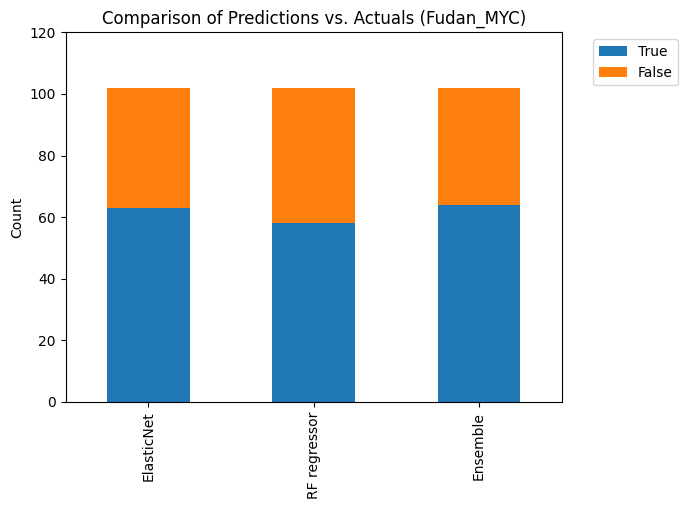

In [ ]:
myc_ensemble = get_pred_vs_actual_comparison(df_elastic = elastic_myc_mean,
                                             df_rf = rf_myc_mean,
                                             df_ensemble = ensemble_myc_mean,
                                             df_lcms = lcms_myc_mean,
                                             case_study_name = 'Fudan_MYC')

In [ ]:
from scipy.stats import ttest_ind

In [ ]:
def get_statistically_significant_metabolites(df, df_mean, pval_threshold):
  grouped = df.groupby('MYC')
  mut = grouped.get_group('Gain/Amplification').drop(columns=['MYC'])
  wt = grouped.get_group('Loss/No_change').drop(columns=['MYC'])
  results = {}
  for col in mut.columns:
    t_stat, p_value = ttest_ind(mut[col], wt[col])
    results[col] = {'T-statistic': t_stat, 'P-value': p_value}
  results_df = pd.DataFrame(results).T
  results_df.index = mut.columns
  df_mean = df_mean.copy()
  df_mean.index.name = None
  res = pd.concat([df_mean, results_df], axis = 'columns')
  return res

In [ ]:
myc_sig = get_statistically_significant_metabolites(df = lcms_myc, df_mean = lcms_myc_mean,  pval_threshold = 0.05)
myc_sig.head(2)
myc_sig_metabolites = list(myc_sig[myc_sig['P-value'] < 0.05].index)

Correctly predicted metabolites from Elastic Net: ['HMDB0001173', 'HMDB0000294', 'HMDB0003337', 'HMDB0000148', 'HMDB0000071', 'HMDB0002259', 'HMDB0006344', 'HMDB0000594', 'HMDB0000562', 'HMDB0000826', 'HMDB0000532', 'HMDB0000056']
Correctly predicted metabolites from Random forest regressor: ['HMDB0000294', 'HMDB0001262', 'HMDB0003337', 'HMDB0000148', 'HMDB0002259', 'HMDB0006344', 'HMDB0000211', 'HMDB0000594', 'HMDB0000562', 'HMDB0000826', 'HMDB0000532', 'HMDB0000056']
Correctly predicted metabolites from Ensemble: ['HMDB0001173', 'HMDB0003337', 'HMDB0000148', 'HMDB0000071', 'HMDB0002259', 'HMDB0006344', 'HMDB0000594', 'HMDB0000562', 'HMDB0000826', 'HMDB0000532', 'HMDB0000056']


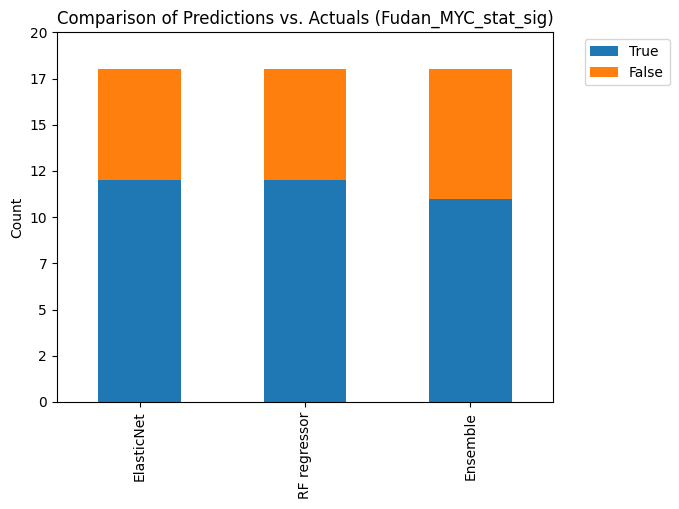

In [ ]:
#For statistically siginificant metabolites
get_pred_vs_actual_comparison(df_elastic = elastic_myc_mean.loc[myc_sig_metabolites],
                              df_rf = rf_myc_mean.loc[myc_sig_metabolites],
                              df_ensemble = ensemble_myc_mean.loc[myc_sig_metabolites],
                              df_lcms = lcms_myc_mean.loc[myc_sig_metabolites],
                              case_study_name = 'Fudan_MYC_stat_sig')

#PI3K case study

In [ ]:
pi3k = cnv[['Transcriptomic_Sample', 'PI3K_activity_status']]
pi3k

,Transcriptomic_Sample,PI3K_activity_status
0,FUSCCTNBC001,PI3K_PTEN_mut
1,FUSCCTNBC003,NaN
2,FUSCCTNBC004,PI3K_PTEN_mut
3,FUSCCTNBC005,PI3K_PTEN_mut
4,FUSCCTNBC006,PI3K_PTEN_WT
...,...,...
313,FUSCCTNBC491,NaN
314,FUSCCTNBC492,NaN
315,FUSCCTNBC493,NaN
316,FUSCCTNBC494,NaN


In [ ]:
pi3k.PI3K_activity_status.value_counts()

,count
PI3K_activity_status,
PI3K_PTEN_mut,181
PI3K_PTEN_WT,92


In [ ]:
pi3k = pi3k[['Transcriptomic_Sample', 'PI3K_activity_status']]
pi3k = pi3k.dropna()
pi3k = pi3k.set_index('Transcriptomic_Sample')
pi3k

,PI3K_activity_status
Transcriptomic_Sample,
FUSCCTNBC001,PI3K_PTEN_mut
FUSCCTNBC004,PI3K_PTEN_mut
FUSCCTNBC005,PI3K_PTEN_mut
FUSCCTNBC006,PI3K_PTEN_WT
FUSCCTNBC007,PI3K_PTEN_mut
...,...
FUSCCTNBC465,PI3K_PTEN_mut
FUSCCTNBC467,PI3K_PTEN_WT
FUSCCTNBC468,PI3K_PTEN_mut


In [ ]:
pi3k = pi3k.loc[pi3k.index.intersection(lcms.index)]
pi3k

,PI3K_activity_status
FUSCCTNBC001,PI3K_PTEN_mut
FUSCCTNBC004,PI3K_PTEN_mut
FUSCCTNBC005,PI3K_PTEN_mut
FUSCCTNBC006,PI3K_PTEN_WT
FUSCCTNBC007,PI3K_PTEN_mut
...,...
FUSCCTNBC441,PI3K_PTEN_WT
FUSCCTNBC443,PI3K_PTEN_WT
FUSCCTNBC451,PI3K_PTEN_WT
FUSCCTNBC456,PI3K_PTEN_mut


In [ ]:
pi3k.isna().sum()

,0
PI3K_activity_status,0


In [ ]:
pi3k_status = []
for i in pi3k.PI3K_activity_status:
  if i  == 'PI3K_PTEN_WT':
    pi3k_status.append('WT')
  else:
    pi3k_status.append('MUT')

In [ ]:
pi3k['PI3K'] = pi3k_status
pi3k = pi3k.drop('PI3K_activity_status', axis = 'columns')
pi3k

,PI3K
FUSCCTNBC001,MUT
FUSCCTNBC004,MUT
FUSCCTNBC005,MUT
FUSCCTNBC006,WT
FUSCCTNBC007,MUT
...,...
FUSCCTNBC441,WT
FUSCCTNBC443,WT
FUSCCTNBC451,WT
FUSCCTNBC456,MUT


In [ ]:
pi3k.PI3K.value_counts()

,count
PI3K,
MUT,131
WT,71


In [ ]:
def select_and_add_pi3k_status(df, pi3k_df):
  common_index = list(df.index.intersection(pi3k_df.index))
  res = pd.concat([pi3k_df.loc[common_index], df.loc[common_index]], axis = 'columns')
  return res

In [ ]:
rna_pred_ensemble

,No_id,No_id,No_id,No_id,No_id,HMDB0010386,HMDB0011567,No_id,No_id,No_id,...,HMDB0000294,HMDB0000296,HMDB0000883,HMDB0029127,HMDB0000292,HMDB0000299,HMDB0000807,HMDB0001264,HMDB0000243,HMDB0000263
FUSCCTNBC182,21.257539,19.341044,26.716465,22.351462,20.128613,21.733506,21.645404,21.782142,19.303347,23.342090,...,21.960296,19.439959,25.511360,18.813524,22.960210,16.866518,19.363134,15.509789,21.956034,19.696538
FUSCCTNBC203,22.321402,20.242076,27.923796,23.017173,20.778425,22.941351,21.595815,22.686360,20.205131,23.607850,...,22.188230,19.108198,26.088291,20.890361,22.963302,17.527011,19.478805,16.345176,23.577163,20.934048
FUSCCTNBC202,22.698735,21.405273,28.617816,23.646420,22.667385,24.339670,22.861078,24.014327,20.579690,23.926371,...,22.394722,18.472518,26.268270,21.549338,22.886418,17.312622,19.455189,16.180463,24.300367,20.337122
FUSCCTNBC252,21.698935,20.173799,27.588583,22.843352,20.919581,22.241238,21.844499,22.418764,19.698438,24.068988,...,22.009602,18.465016,25.643361,19.917769,22.905278,17.255196,19.997655,17.521807,24.296756,18.870677
FUSCCTNBC187,22.557134,20.766887,29.659165,23.549326,20.630998,23.774179,20.922438,21.953605,19.399706,22.897108,...,23.498958,16.780410,25.477206,23.179816,21.125679,17.294350,19.471490,17.502986,26.061383,19.621418
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FUSCCTNBC478,22.684033,20.606208,29.250986,23.403300,19.882450,23.446141,20.431470,21.484129,18.982401,22.842289,...,22.976977,16.965995,25.031926,22.897062,20.845593,17.547740,19.518465,17.796936,25.911862,19.217389
FUSCCTNBC475,24.691836,23.139770,35.263049,25.613289,22.301363,26.771474,21.119369,23.462307,19.754999,23.535627,...,23.546033,11.337636,24.572268,27.875643,18.941019,18.569607,20.816533,19.275283,32.504283,19.981627
FUSCCTNBC476,21.669751,20.245428,28.950455,23.495459,21.541353,23.155518,23.007511,23.933993,20.686522,24.899856,...,21.306938,19.309716,25.974144,19.620094,24.107782,17.376638,19.962356,15.683751,23.320258,20.085730
FUSCCTNBC479,22.389090,20.428215,27.306263,22.627311,20.476323,23.399521,21.269190,22.031881,19.681801,23.177444,...,22.973665,18.419362,25.378693,21.607731,22.025441,17.729708,19.260324,17.557014,23.792761,19.527136


In [ ]:
lcms_pi3k = select_and_add_pi3k_status(df = lcms, pi3k_df = pi3k)
elastic_pred_pi3k = select_and_add_pi3k_status(df = rna_pred_elastic, pi3k_df = pi3k)
rf_pred_pi3k = select_and_add_pi3k_status(df = rna_pred_rf, pi3k_df = pi3k)
ensemble_pred_pi3k = select_and_add_pi3k_status(df = rna_pred_ensemble, pi3k_df = pi3k)

In [ ]:
lcms_pi3k.head(2)

,PI3K,HMDB0000050,HMDB0003229,HMDB0000220,HMDB0000214,HMDB0001173,HMDB0000089,HMDB0000161,HMDB0000939,HMDB0000126,...,HMDB0000532,HMDB0000714,HMDB0011172,HMDB0000243,HMDB0000011,HMDB0000094,HMDB0000194,HMDB0002994,HMDB0000125,HMDB0000056
FUSCCTNBC034,MUT,19.946314,17.235322,20.114399,14.476746,16.179132,12.576957,15.723341,15.005800,17.177439,...,15.69098,13.677279,14.720672,21.237481,10.987264,17.051804,16.901162,16.410385,13.688250,13.189207
FUSCCTNBC057,WT,23.314930,16.275033,19.219896,13.274669,21.726481,13.741888,15.808763,16.490914,16.084725,...,16.33560,14.532599,16.305634,21.514610,12.237807,17.220444,15.649481,15.626850,14.808763,13.173677


In [ ]:
def get_common_metabolites(df1, df2, df3, df4):
  common_cols = df1.columns.intersection(df2.columns)
  common_cols = common_cols.intersection(df3.columns)
  common_cols = common_cols.intersection(df4.columns)
  return list(common_cols)

common_metabolites = get_common_metabolites(lcms_pi3k, elastic_pred_pi3k, rf_pred_pi3k, ensemble_pred_pi3k)
len(common_metabolites)

103

In [ ]:
lcms_pi3k = lcms_pi3k[common_metabolites]
elastic_pred_pi3k = elastic_pred_pi3k[common_metabolites]
rf_pred_pi3k = rf_pred_pi3k[common_metabolites]
ensemble_pred_pi3k = ensemble_pred_pi3k[common_metabolites]

In [ ]:
def get_mean_and_direction_of_change_by_group(df):
  res = df.groupby('PI3K').mean()
  res = res.transpose()
  res['Higher_in_altered'] = res['MUT'] > res['WT']
  res.replace({True : 'yes', False : 'no'}, inplace = True)
  return res

In [ ]:
lcms_pi3k_mean = get_mean_and_direction_of_change_by_group(lcms_pi3k)
elastic_pi3k_mean = get_mean_and_direction_of_change_by_group(elastic_pred_pi3k)
rf_pi3k_mean = get_mean_and_direction_of_change_by_group(rf_pred_pi3k)
ensemble_pi3k_mean = get_mean_and_direction_of_change_by_group(ensemble_pred_pi3k)

In [ ]:
elastic_pi3k_mean = elastic_pi3k_mean.loc[lcms_pi3k_mean.index][~elastic_pi3k_mean.index.duplicated(keep='first')]
rf_pi3k_mean = rf_pi3k_mean.loc[lcms_pi3k_mean.index][~rf_pi3k_mean.index.duplicated(keep='first')]
ensemble_pi3k_mean = ensemble_pi3k_mean.loc[lcms_pi3k_mean.index][~ensemble_pi3k_mean.index.duplicated(keep='first')]

In [ ]:
def get_pred_vs_actual_comparison(df_elastic, df_rf, df_ensemble, df_lcms, case_study_name):
  #Elastic Net
  df1 = pd.concat([df_elastic.rename(columns = {'Higher_in_altered' : 'prediction'})['prediction'], df_lcms.rename(columns = {'Higher_in_altered' : 'actual'})['actual']], axis = 'columns')
  df1['comparison'] = df1['prediction'] == df1['actual']
  print('Correctly predicted metabolites from Elastic Net: ' + str(list(df1[df1['comparison'] == True].index)))
  res1 = pd.DataFrame(df1['comparison'].value_counts())
  res1.rename(columns = {'count' : 'ElasticNet'}, inplace = True)

  #Random forest regressor
  df2 = pd.concat([df_rf.rename(columns = {'Higher_in_altered' : 'prediction'})['prediction'], df_lcms.rename(columns = {'Higher_in_altered' : 'actual'})['actual']], axis = 'columns')
  df2['comparison'] = df2['prediction'] == df2['actual']
  print('Correctly predicted metabolites from Random forest regressor: ' + str(list(df2[df2['comparison'] == True].index)))
  res2 = pd.DataFrame(df2['comparison'].value_counts())
  res2.rename(columns = {'count' : 'RF regressor'}, inplace = True)

  #Ensemble
  df3 = pd.concat([df_ensemble.rename(columns = {'Higher_in_altered' : 'prediction'})['prediction'], df_lcms.rename(columns = {'Higher_in_altered' : 'actual'})['actual']], axis = 'columns')
  df3['comparison'] = df3['prediction'] == df3['actual']
  print('Correctly predicted metabolites from Ensemble: ' + str(list(df3[df3['comparison'] == True].index)))
  ensemble_mets = list(df3[df3['comparison'] == True].index)
  res3 = pd.DataFrame(df3['comparison'].value_counts())
  res3.rename(columns = {'count' : 'Ensemble'}, inplace = True)

  #Final result
  res = pd.concat([res1, res2, res3], axis = 'columns')

  res_transposed = res.T
  res_transposed.plot(kind='bar', stacked=True)
  locs, labels = plt.yticks()

  new_labels = [int(float(label.get_text())) for label in labels]
  plt.yticks(locs, new_labels)

  plt.title(f'Comparison of Predictions vs. Actuals ({case_study_name})')
  plt.ylabel('Count')
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
  plt.savefig(f'drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/{case_study_name}_pred_vs_actual.svg', bbox_inches = 'tight')
  plt.show()

  return ensemble_mets

Correctly predicted metabolites from Elastic Net: ['HMDB0000050', 'HMDB0003229', 'HMDB0000220', 'HMDB0000214', 'HMDB0001173', 'HMDB0000161', 'HMDB0000939', 'HMDB0000696', 'HMDB0000162', 'HMDB0000517', 'HMDB0001406', 'HMDB0001565', 'HMDB0000133', 'HMDB0000641', 'HMDB0000159', 'HMDB0000848', 'HMDB0001262', 'HMDB0000300', 'HMDB0000195', 'HMDB0000904', 'HMDB0000086', 'HMDB0000177', 'HMDB0000638', 'HMDB0000158', 'HMDB0000827', 'HMDB0000167', 'HMDB0000254', 'HMDB0000043', 'HMDB0000870', 'HMDB0000064', 'HMDB0000071', 'HMDB0000625', 'HMDB0000168', 'HMDB0000759', 'HMDB0002259', 'HMDB0000191', 'HMDB0000182', 'HMDB0006344', 'HMDB0000682', 'HMDB0000594', 'HMDB0000687', 'HMDB0000156', 'HMDB0000755', 'HMDB0000767', 'HMDB0000210', 'HMDB0028691', 'HMDB0000252', 'HMDB0000139', 'HMDB0002000', 'HMDB0000695', 'HMDB0000283', 'HMDB0000562', 'HMDB0000289', 'HMDB0000660', 'HMDB0000134', 'HMDB0000826', 'HMDB0000532', 'HMDB0000714', 'HMDB0011172', 'HMDB0000243', 'HMDB0000011', 'HMDB0000194', 'HMDB0002994']
Corr

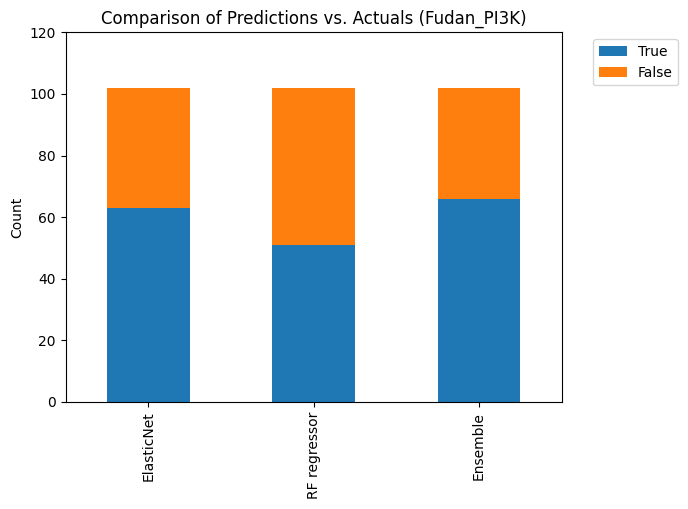

In [ ]:
pi3k_ensemble = get_pred_vs_actual_comparison(df_elastic = elastic_pi3k_mean,
                                              df_rf = rf_pi3k_mean,
                                              df_ensemble = ensemble_pi3k_mean,
                                              df_lcms = lcms_pi3k_mean,
                                              case_study_name = 'Fudan_PI3K')

In [ ]:
from scipy.stats import ttest_ind

In [ ]:
def get_statistically_significant_metabolites(df, df_mean, pval_threshold):
  grouped = df.groupby('PI3K')
  mut = grouped.get_group('MUT').drop(columns=['PI3K'])
  wt = grouped.get_group('WT').drop(columns=['PI3K'])
  results = {}
  for col in mut.columns:
    t_stat, p_value = ttest_ind(mut[col], wt[col])
    results[col] = {'T-statistic': t_stat, 'P-value': p_value}
  results_df = pd.DataFrame(results).T
  results_df.index = mut.columns
  df_mean = df_mean.copy()
  df_mean.index.name = None
  res = pd.concat([df_mean, results_df], axis = 'columns')
  return res

In [ ]:
pi3k_sig = get_statistically_significant_metabolites(df = lcms_pi3k, df_mean = lcms_pi3k_mean,  pval_threshold = 0.05)
pi3k_sig.head(2)
pi3k_sig_metabolites = list(pi3k_sig[pi3k_sig['P-value'] < 0.05].index)

Correctly predicted metabolites from Elastic Net: ['HMDB0000625', 'HMDB0000755', 'HMDB0028691']
Correctly predicted metabolites from Random forest regressor: ['HMDB0000089', 'HMDB0000625']
Correctly predicted metabolites from Ensemble: ['HMDB0000089', 'HMDB0000625', 'HMDB0000755', 'HMDB0028691']


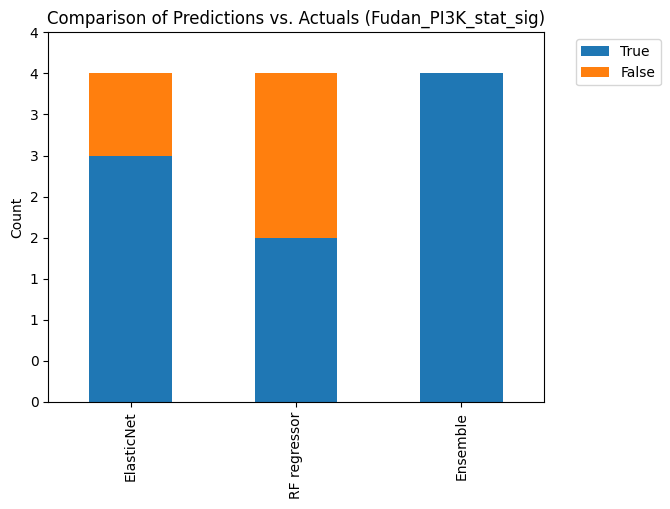

In [ ]:
#For statistically siginificant metabolites
get_pred_vs_actual_comparison(df_elastic = elastic_pi3k_mean.loc[pi3k_sig_metabolites],
                              df_rf = rf_pi3k_mean.loc[pi3k_sig_metabolites],
                              df_ensemble = ensemble_pi3k_mean.loc[pi3k_sig_metabolites],
                              df_lcms = lcms_pi3k_mean.loc[pi3k_sig_metabolites],
                              case_study_name = 'Fudan_PI3K_stat_sig')

#Case study common metabolites

In [ ]:
myc = myc_ensemble
pi3k = pi3k_ensemble

In [ ]:
len(myc)

64

In [ ]:
len(pi3k)

66

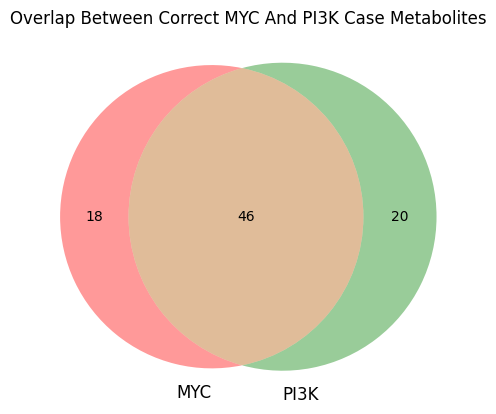

In [ ]:
from matplotlib_venn import venn2

set1 = set(myc)
set2 = set(pi3k)

venn2([set1, set2], set_labels=('MYC', 'PI3K'))
plt.title('Overlap Between Correct MYC And PI3K Case Metabolites')
plt.savefig('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/Fudan_MYC_PI3K_common_correct_metabolites_venn.svg', bbox_inches = 'tight')
plt.show()

In [ ]:
common_myc_pi3k = []
for i in set1.intersection(set2):
  common_myc_pi3k.append(i)

len(common_myc_pi3k)

46

In [ ]:
with open('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/Fudan_MYC_PI3K_common_correct_metabolites.pkl', 'wb') as file:
    pickle.dump(common_myc_pi3k, file)

#Extra comparisons

In [12]:
'''
PI3K
Correctly predicted metabolites from Elastic Net: ['HMDB0000050', 'HMDB0003229', 'HMDB0000220', 'HMDB0000214', 'HMDB0001173', 'HMDB0000161', 'HMDB0000939', 'HMDB0000696', 'HMDB0000162', 'HMDB0000517', 'HMDB0001406', 'HMDB0001565', 'HMDB0000133', 'HMDB0000641', 'HMDB0000159', 'HMDB0000848', 'HMDB0001262', 'HMDB0000300', 'HMDB0000195', 'HMDB0000904', 'HMDB0000086', 'HMDB0000177', 'HMDB0000638', 'HMDB0000158', 'HMDB0000827', 'HMDB0000167', 'HMDB0000254', 'HMDB0000043', 'HMDB0000870', 'HMDB0000064', 'HMDB0000071', 'HMDB0000625', 'HMDB0000168', 'HMDB0000759', 'HMDB0002259', 'HMDB0000191', 'HMDB0000182', 'HMDB0006344', 'HMDB0000682', 'HMDB0000594', 'HMDB0000687', 'HMDB0000156', 'HMDB0000755', 'HMDB0000767', 'HMDB0000210', 'HMDB0028691', 'HMDB0000252', 'HMDB0000139', 'HMDB0002000', 'HMDB0000695', 'HMDB0000283', 'HMDB0000562', 'HMDB0000289', 'HMDB0000660', 'HMDB0000134', 'HMDB0000826', 'HMDB0000532', 'HMDB0000714', 'HMDB0011172', 'HMDB0000243', 'HMDB0000011', 'HMDB0000194', 'HMDB0002994']
Correctly predicted metabolites from Random forest regressor: ['HMDB0001173', 'HMDB0000089', 'HMDB0000126', 'HMDB0000696', 'HMDB0000294', 'HMDB0000201', 'HMDB0000517', 'HMDB0000673', 'HMDB0001406', 'HMDB0001565', 'HMDB0000641', 'HMDB0000159', 'HMDB0000848', 'HMDB0001262', 'HMDB0001348', 'HMDB0000251', 'HMDB0000300', 'HMDB0011737', 'HMDB0000169', 'HMDB0003337', 'HMDB0000148', 'HMDB0000086', 'HMDB0000177', 'HMDB0000158', 'HMDB0000267', 'HMDB0000827', 'HMDB0000043', 'HMDB0000625', 'HMDB0000812', 'HMDB0000759', 'HMDB0000943', 'HMDB0000182', 'HMDB0000883', 'HMDB0006344', 'HMDB0000123', 'HMDB0000062', 'HMDB0000594', 'HMDB0000687', 'HMDB0000156', 'HMDB0000210', 'HMDB0000131', 'HMDB0000262', 'HMDB0000139', 'HMDB0000695', 'HMDB0001316', 'HMDB0000283', 'HMDB0000562', 'HMDB0000289', 'HMDB0000134', 'HMDB0000766', 'HMDB0000243']
Correctly predicted metabolites from Ensemble: ['HMDB0003229', 'HMDB0001173', 'HMDB0000089', 'HMDB0000161', 'HMDB0000939', 'HMDB0000126', 'HMDB0000696', 'HMDB0000162', 'HMDB0000806', 'HMDB0000517', 'HMDB0000673', 'HMDB0001406', 'HMDB0001565', 'HMDB0000641', 'HMDB0000159', 'HMDB0000848', 'HMDB0001262', 'HMDB0001348', 'HMDB0000251', 'HMDB0000300', 'HMDB0011737', 'HMDB0000086', 'HMDB0000158', 'HMDB0000267', 'HMDB0000827', 'HMDB0011503', 'HMDB0000167', 'HMDB0000929', 'HMDB0000254', 'HMDB0000043', 'HMDB0000870', 'HMDB0000064', 'HMDB0000071', 'HMDB0003045', 'HMDB0000625', 'HMDB0000812', 'HMDB0000168', 'HMDB0000759', 'HMDB0000191', 'HMDB0000943', 'HMDB0000182', 'HMDB0006344', 'HMDB0000687', 'HMDB0000156', 'HMDB0000755', 'HMDB0000767', 'HMDB0000210', 'HMDB0028691', 'HMDB0000299', 'HMDB0000262', 'HMDB0000252', 'HMDB0000139', 'HMDB0002000', 'HMDB0000695', 'HMDB0001316', 'HMDB0000283', 'HMDB0000562', 'HMDB0000289', 'HMDB0000660', 'HMDB0000134', 'HMDB0000826', 'HMDB0000532', 'HMDB0000714', 'HMDB0000243', 'HMDB0000011', 'HMDB0000194']

MYC
Correctly predicted metabolites from Elastic Net: ['HMDB0000220', 'HMDB0000214', 'HMDB0001173', 'HMDB0000939', 'HMDB0000162', 'HMDB0000294', 'HMDB0000806', 'HMDB0000201', 'HMDB0000517', 'HMDB0000673', 'HMDB0001406', 'HMDB0000641', 'HMDB0000159', 'HMDB0000848', 'HMDB0000296', 'HMDB0001348', 'HMDB0000251', 'HMDB0000300', 'HMDB0000169', 'HMDB0003337', 'HMDB0000034', 'HMDB0000148', 'HMDB0000904', 'HMDB0000086', 'HMDB0000638', 'HMDB0000827', 'HMDB0011503', 'HMDB0000929', 'HMDB0000043', 'HMDB0000870', 'HMDB0000071', 'HMDB0003045', 'HMDB0000625', 'HMDB0000812', 'HMDB0000759', 'HMDB0002259', 'HMDB0000182', 'HMDB0006344', 'HMDB0000682', 'HMDB0000187', 'HMDB0000062', 'HMDB0000594', 'HMDB0000210', 'HMDB0028691', 'HMDB0000131', 'HMDB0000262', 'HMDB0000163', 'HMDB0000252', 'HMDB0000139', 'HMDB0002000', 'HMDB0000695', 'HMDB0001316', 'HMDB0000562', 'HMDB0000289', 'HMDB0000660', 'HMDB0000134', 'HMDB0000826', 'HMDB0000532', 'HMDB0000714', 'HMDB0000094', 'HMDB0002994', 'HMDB0000125', 'HMDB0000056']
Correctly predicted metabolites from Random forest regressor: ['HMDB0003229', 'HMDB0000214', 'HMDB0000939', 'HMDB0000126', 'HMDB0000696', 'HMDB0000162', 'HMDB0000294', 'HMDB0000806', 'HMDB0000517', 'HMDB0000673', 'HMDB0001406', 'HMDB0000133', 'HMDB0000641', 'HMDB0000159', 'HMDB0000848', 'HMDB0000296', 'HMDB0001262', 'HMDB0001348', 'HMDB0000251', 'HMDB0011737', 'HMDB0000169', 'HMDB0003337', 'HMDB0000148', 'HMDB0000904', 'HMDB0000086', 'HMDB0000638', 'HMDB0000158', 'HMDB0011503', 'HMDB0000929', 'HMDB0000043', 'HMDB0000812', 'HMDB0002259', 'HMDB0000191', 'HMDB0000182', 'HMDB0006344', 'HMDB0000211', 'HMDB0000682', 'HMDB0000062', 'HMDB0000594', 'HMDB0000156', 'HMDB0000210', 'HMDB0028691', 'HMDB0000163', 'HMDB0000252', 'HMDB0000139', 'HMDB0002000', 'HMDB0001316', 'HMDB0000562', 'HMDB0000289', 'HMDB0000660', 'HMDB0000134', 'HMDB0000826', 'HMDB0000532', 'HMDB0000714', 'HMDB0000094', 'HMDB0002994', 'HMDB0000125', 'HMDB0000056']
Correctly predicted metabolites from Ensemble: ['HMDB0003229', 'HMDB0000220', 'HMDB0000214', 'HMDB0001173', 'HMDB0000939', 'HMDB0000696', 'HMDB0000162', 'HMDB0000806', 'HMDB0000201', 'HMDB0000517', 'HMDB0000673', 'HMDB0001406', 'HMDB0000133', 'HMDB0000641', 'HMDB0000159', 'HMDB0000848', 'HMDB0000296', 'HMDB0001348', 'HMDB0000251', 'HMDB0000300', 'HMDB0011737', 'HMDB0000169', 'HMDB0003337', 'HMDB0000148', 'HMDB0000904', 'HMDB0000086', 'HMDB0000638', 'HMDB0000827', 'HMDB0011503', 'HMDB0000929', 'HMDB0000043', 'HMDB0000870', 'HMDB0000071', 'HMDB0003045', 'HMDB0000625', 'HMDB0000812', 'HMDB0000759', 'HMDB0002259', 'HMDB0000191', 'HMDB0000182', 'HMDB0006344', 'HMDB0000187', 'HMDB0000062', 'HMDB0000594', 'HMDB0000156', 'HMDB0000210', 'HMDB0028691', 'HMDB0000131', 'HMDB0000262', 'HMDB0000163', 'HMDB0000252', 'HMDB0000139', 'HMDB0002000', 'HMDB0000695', 'HMDB0001316', 'HMDB0000562', 'HMDB0000289', 'HMDB0000660', 'HMDB0000134', 'HMDB0000826', 'HMDB0000532', 'HMDB0000714', 'HMDB0000125', 'HMDB0000056']

'''

"\nPI3K\nCorrectly predicted metabolites from Elastic Net: ['HMDB0000050', 'HMDB0003229', 'HMDB0000220', 'HMDB0000214', 'HMDB0001173', 'HMDB0000161', 'HMDB0000939', 'HMDB0000696', 'HMDB0000162', 'HMDB0000517', 'HMDB0001406', 'HMDB0001565', 'HMDB0000133', 'HMDB0000641', 'HMDB0000159', 'HMDB0000848', 'HMDB0001262', 'HMDB0000300', 'HMDB0000195', 'HMDB0000904', 'HMDB0000086', 'HMDB0000177', 'HMDB0000638', 'HMDB0000158', 'HMDB0000827', 'HMDB0000167', 'HMDB0000254', 'HMDB0000043', 'HMDB0000870', 'HMDB0000064', 'HMDB0000071', 'HMDB0000625', 'HMDB0000168', 'HMDB0000759', 'HMDB0002259', 'HMDB0000191', 'HMDB0000182', 'HMDB0006344', 'HMDB0000682', 'HMDB0000594', 'HMDB0000687', 'HMDB0000156', 'HMDB0000755', 'HMDB0000767', 'HMDB0000210', 'HMDB0028691', 'HMDB0000252', 'HMDB0000139', 'HMDB0002000', 'HMDB0000695', 'HMDB0000283', 'HMDB0000562', 'HMDB0000289', 'HMDB0000660', 'HMDB0000134', 'HMDB0000826', 'HMDB0000532', 'HMDB0000714', 'HMDB0011172', 'HMDB0000243', 'HMDB0000011', 'HMDB0000194', 'HMDB00029

In [13]:
pi3k_elastic = ['HMDB0000050', 'HMDB0003229', 'HMDB0000220', 'HMDB0000214', 'HMDB0001173', 'HMDB0000161', 'HMDB0000939', 'HMDB0000696', 'HMDB0000162', 'HMDB0000517', 'HMDB0001406', 'HMDB0001565', 'HMDB0000133', 'HMDB0000641', 'HMDB0000159', 'HMDB0000848', 'HMDB0001262', 'HMDB0000300', 'HMDB0000195', 'HMDB0000904', 'HMDB0000086', 'HMDB0000177', 'HMDB0000638', 'HMDB0000158', 'HMDB0000827', 'HMDB0000167', 'HMDB0000254', 'HMDB0000043', 'HMDB0000870', 'HMDB0000064', 'HMDB0000071', 'HMDB0000625', 'HMDB0000168', 'HMDB0000759', 'HMDB0002259', 'HMDB0000191', 'HMDB0000182', 'HMDB0006344', 'HMDB0000682', 'HMDB0000594', 'HMDB0000687', 'HMDB0000156', 'HMDB0000755', 'HMDB0000767', 'HMDB0000210', 'HMDB0028691', 'HMDB0000252', 'HMDB0000139', 'HMDB0002000', 'HMDB0000695', 'HMDB0000283', 'HMDB0000562', 'HMDB0000289', 'HMDB0000660', 'HMDB0000134', 'HMDB0000826', 'HMDB0000532', 'HMDB0000714', 'HMDB0011172', 'HMDB0000243', 'HMDB0000011', 'HMDB0000194', 'HMDB0002994']
pi3k_rf = ['HMDB0001173', 'HMDB0000089', 'HMDB0000126', 'HMDB0000696', 'HMDB0000294', 'HMDB0000201', 'HMDB0000517', 'HMDB0000673', 'HMDB0001406', 'HMDB0001565', 'HMDB0000641', 'HMDB0000159', 'HMDB0000848', 'HMDB0001262', 'HMDB0001348', 'HMDB0000251', 'HMDB0000300', 'HMDB0011737', 'HMDB0000169', 'HMDB0003337', 'HMDB0000148', 'HMDB0000086', 'HMDB0000177', 'HMDB0000158', 'HMDB0000267', 'HMDB0000827', 'HMDB0000043', 'HMDB0000625', 'HMDB0000812', 'HMDB0000759', 'HMDB0000943', 'HMDB0000182', 'HMDB0000883', 'HMDB0006344', 'HMDB0000123', 'HMDB0000062', 'HMDB0000594', 'HMDB0000687', 'HMDB0000156', 'HMDB0000210', 'HMDB0000131', 'HMDB0000262', 'HMDB0000139', 'HMDB0000695', 'HMDB0001316', 'HMDB0000283', 'HMDB0000562', 'HMDB0000289', 'HMDB0000134', 'HMDB0000766', 'HMDB0000243']
pi3k_ens = ['HMDB0003229', 'HMDB0001173', 'HMDB0000089', 'HMDB0000161', 'HMDB0000939', 'HMDB0000126', 'HMDB0000696', 'HMDB0000162', 'HMDB0000806', 'HMDB0000517', 'HMDB0000673', 'HMDB0001406', 'HMDB0001565', 'HMDB0000641', 'HMDB0000159', 'HMDB0000848', 'HMDB0001262', 'HMDB0001348', 'HMDB0000251', 'HMDB0000300', 'HMDB0011737', 'HMDB0000086', 'HMDB0000158', 'HMDB0000267', 'HMDB0000827', 'HMDB0011503', 'HMDB0000167', 'HMDB0000929', 'HMDB0000254', 'HMDB0000043', 'HMDB0000870', 'HMDB0000064', 'HMDB0000071', 'HMDB0003045', 'HMDB0000625', 'HMDB0000812', 'HMDB0000168', 'HMDB0000759', 'HMDB0000191', 'HMDB0000943', 'HMDB0000182', 'HMDB0006344', 'HMDB0000687', 'HMDB0000156', 'HMDB0000755', 'HMDB0000767', 'HMDB0000210', 'HMDB0028691', 'HMDB0000299', 'HMDB0000262', 'HMDB0000252', 'HMDB0000139', 'HMDB0002000', 'HMDB0000695', 'HMDB0001316', 'HMDB0000283', 'HMDB0000562', 'HMDB0000289', 'HMDB0000660', 'HMDB0000134', 'HMDB0000826', 'HMDB0000532', 'HMDB0000714', 'HMDB0000243', 'HMDB0000011', 'HMDB0000194']


In [14]:
myc_elastic = ['HMDB0000220', 'HMDB0000214', 'HMDB0001173', 'HMDB0000939', 'HMDB0000162', 'HMDB0000294', 'HMDB0000806', 'HMDB0000201', 'HMDB0000517', 'HMDB0000673', 'HMDB0001406', 'HMDB0000641', 'HMDB0000159', 'HMDB0000848', 'HMDB0000296', 'HMDB0001348', 'HMDB0000251', 'HMDB0000300', 'HMDB0000169', 'HMDB0003337', 'HMDB0000034', 'HMDB0000148', 'HMDB0000904', 'HMDB0000086', 'HMDB0000638', 'HMDB0000827', 'HMDB0011503', 'HMDB0000929', 'HMDB0000043', 'HMDB0000870', 'HMDB0000071', 'HMDB0003045', 'HMDB0000625', 'HMDB0000812', 'HMDB0000759', 'HMDB0002259', 'HMDB0000182', 'HMDB0006344', 'HMDB0000682', 'HMDB0000187', 'HMDB0000062', 'HMDB0000594', 'HMDB0000210', 'HMDB0028691', 'HMDB0000131', 'HMDB0000262', 'HMDB0000163', 'HMDB0000252', 'HMDB0000139', 'HMDB0002000', 'HMDB0000695', 'HMDB0001316', 'HMDB0000562', 'HMDB0000289', 'HMDB0000660', 'HMDB0000134', 'HMDB0000826', 'HMDB0000532', 'HMDB0000714', 'HMDB0000094', 'HMDB0002994', 'HMDB0000125', 'HMDB0000056']
myc_rf = ['HMDB0003229', 'HMDB0000214', 'HMDB0000939', 'HMDB0000126', 'HMDB0000696', 'HMDB0000162', 'HMDB0000294', 'HMDB0000806', 'HMDB0000517', 'HMDB0000673', 'HMDB0001406', 'HMDB0000133', 'HMDB0000641', 'HMDB0000159', 'HMDB0000848', 'HMDB0000296', 'HMDB0001262', 'HMDB0001348', 'HMDB0000251', 'HMDB0011737', 'HMDB0000169', 'HMDB0003337', 'HMDB0000148', 'HMDB0000904', 'HMDB0000086', 'HMDB0000638', 'HMDB0000158', 'HMDB0011503', 'HMDB0000929', 'HMDB0000043', 'HMDB0000812', 'HMDB0002259', 'HMDB0000191', 'HMDB0000182', 'HMDB0006344', 'HMDB0000211', 'HMDB0000682', 'HMDB0000062', 'HMDB0000594', 'HMDB0000156', 'HMDB0000210', 'HMDB0028691', 'HMDB0000163', 'HMDB0000252', 'HMDB0000139', 'HMDB0002000', 'HMDB0001316', 'HMDB0000562', 'HMDB0000289', 'HMDB0000660', 'HMDB0000134', 'HMDB0000826', 'HMDB0000532', 'HMDB0000714', 'HMDB0000094', 'HMDB0002994', 'HMDB0000125', 'HMDB0000056']
myc_ens = ['HMDB0003229', 'HMDB0000220', 'HMDB0000214', 'HMDB0001173', 'HMDB0000939', 'HMDB0000696', 'HMDB0000162', 'HMDB0000806', 'HMDB0000201', 'HMDB0000517', 'HMDB0000673', 'HMDB0001406', 'HMDB0000133', 'HMDB0000641', 'HMDB0000159', 'HMDB0000848', 'HMDB0000296', 'HMDB0001348', 'HMDB0000251', 'HMDB0000300', 'HMDB0011737', 'HMDB0000169', 'HMDB0003337', 'HMDB0000148', 'HMDB0000904', 'HMDB0000086', 'HMDB0000638', 'HMDB0000827', 'HMDB0011503', 'HMDB0000929', 'HMDB0000043', 'HMDB0000870', 'HMDB0000071', 'HMDB0003045', 'HMDB0000625', 'HMDB0000812', 'HMDB0000759', 'HMDB0002259', 'HMDB0000191', 'HMDB0000182', 'HMDB0006344', 'HMDB0000187', 'HMDB0000062', 'HMDB0000594', 'HMDB0000156', 'HMDB0000210', 'HMDB0028691', 'HMDB0000131', 'HMDB0000262', 'HMDB0000163', 'HMDB0000252', 'HMDB0000139', 'HMDB0002000', 'HMDB0000695', 'HMDB0001316', 'HMDB0000562', 'HMDB0000289', 'HMDB0000660', 'HMDB0000134', 'HMDB0000826', 'HMDB0000532', 'HMDB0000714', 'HMDB0000125', 'HMDB0000056']


In [15]:
elatic_common_ = set(pi3k_elastic).intersection(set(myc_elastic))
rf_common_ = set(pi3k_rf).intersection(set(myc_rf))
ensemble_common_ = set(pi3k_ens).intersection(set(myc_ens))

print('Elastic comparison:' + str(len(elatic_common_)))
print('RF comparison:' + str(len(rf_common_)))
print('Ensemble comparison:' + str(len(ensemble_common_)))

Elastic comparison:39
RF comparison:31
Ensemble comparison:46


In [16]:
plot_df_common = {
    'Elastic comparison':39,
'RF comparison':31,
'Ensemble comparison':46
}

plot_df = pd.DataFrame(plot_df_common, index = [0])
plot_df

,Elastic comparison,RF comparison,Ensemble comparison
0,39,31,46


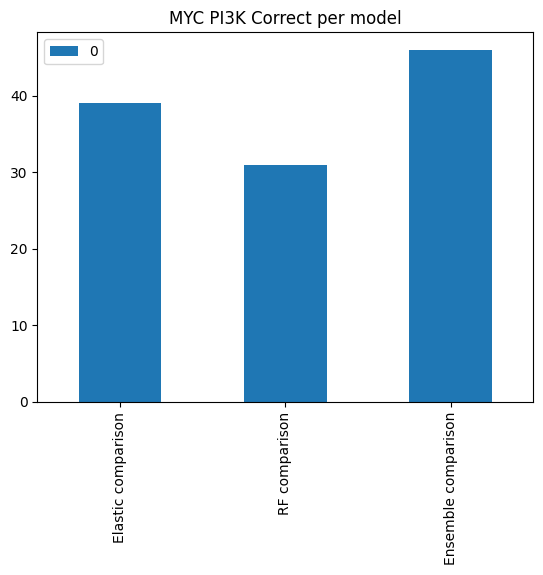

In [17]:
plot_df.T.plot(kind = 'bar')
plt.title('MYC PI3K Correct per model')
plt.savefig('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/Fudan_MYC_PI3K_correct_per_model.svg', bbox_inches = 'tight')
plt.show()

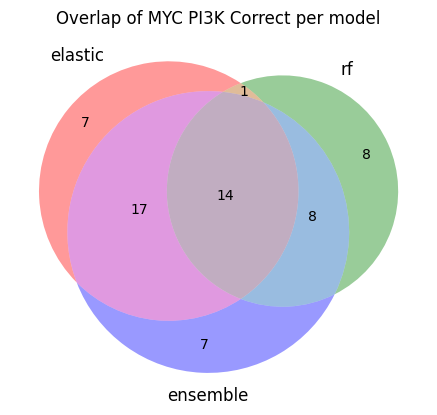

In [18]:
from matplotlib_venn import venn3

set1 = set(elatic_common_)
set2 = set(rf_common_)
set3 = set(ensemble_common_)

venn3([set1, set2, set3], set_labels=('elastic', 'rf', 'ensemble'))
plt.title('Overlap of MYC PI3K Correct per model')
plt.savefig('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/Venn_Fudan_MYC_PI3K_correct_per_model.svg', bbox_inches = 'tight')
plt.show()